In [1]:
import numpy as np
import matplotlib.pyplot as plt
import gc
from pathlib import Path
from define_data_and_variables import pt_config, data, hash_configs, version

In [2]:
base_dir = Path.cwd()

base_path = base_dir / ".." / ".." / ".." / ".." / "data"
data_name = rf"$A_{{{data["dn"][:3]}}}$"
true_sample = np.load(base_path / data["dn"] / version / "true_sample.npy")
int_version = int(version)
true_ages = np.hstack((data["th"], data["th"] - np.cumsum(true_sample) * data["dc"]))
c14_label = r"$^{230}$Th" if "d18o" in data["dn"] else r"$^{14}$C"
measure = "mm" if "d18o" in data["dn"] else "cm"


In [3]:
base_dir = Path.cwd()
sp_dir = base_dir / f"output/{data['dn']}/{version}"
np.random.seed(pt_config['hmcc']['sd'])
sp = np.random.lognormal(mean = data["pm"], sigma = data["ps"], size = (pt_config["nt"], data["N"]))
pt_config["hmcc"]["sp"] = np.ascontiguousarray(sp)

pt_hash = hash_configs(pt_config, data)
output_dir = sp_dir / f"{pt_hash}"

hmc_config = pt_config["hmcc"]

In [4]:
colors = plt.cm.viridis(np.linspace(0, 1, pt_config["nt"]))

[[ 6  6  6 ... 10  2  2]
 [ 4  4  2 ...  2 10 17]
 [ 8  2  4 ... 17 17 10]
 ...
 [10 12 17 ...  7 12 19]
 [14 17 12 ... 19 19 12]
 [17 14 14 ... 14 14 14]]
(20, 99401)
[[ 6  6  6 ... 10  2  2]
 [ 4  4  2 ...  2 10 17]
 [ 8  2  4 ... 17 17 10]
 ...
 [10 12 17 ...  7 12 19]
 [14 17 12 ... 19 19 12]
 [17 14 14 ... 14 14 14]]


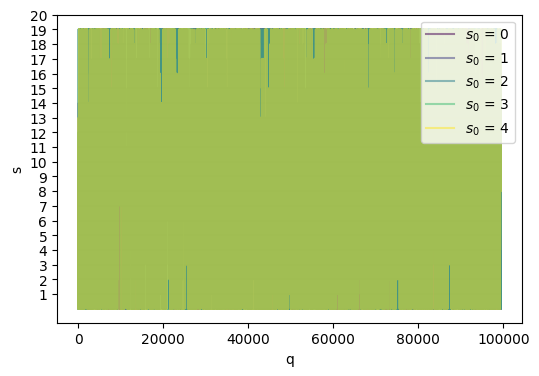

In [5]:
import matplotlib as mpl
cutout = 600
num_starts = 5
temp_indices = np.load(output_dir / "temp_indices.npy", mmap_mode='r')[:, cutout:]
norm = mpl.colors.Normalize(vmin=min(pt_config['bs'][0:num_starts]), vmax=max(pt_config['bs'][0:num_starts]))
cmap = plt.cm.viridis
print(temp_indices)
print(np.shape(temp_indices))
plt.figure(figsize=(6, 4))
xmin = 0
xmax = len(temp_indices[0, :])
# for i in range(len(temp_indices)):
plt.hlines(np.linspace(0, pt_config["nt"] - 1, pt_config["nt"]), linestyle = '--', color = "grey", linewidth = 0.1,  xmin = xmin, xmax = xmax)
for i in range(0, num_starts):
    temp_indices_i = (temp_indices == i).argmax(axis=0)
    plt.plot(np.arange(xmin, xmax, 1), temp_indices_i[xmin:xmax], label = r"$s_0$" + f" = {i}", color = cmap(norm(pt_config['bs'][i])), alpha = 0.5)  
print(temp_indices)
plt.yticks(np.linspace(1, pt_config["nt"], pt_config["nt"]))
plt.ylabel("s")
plt.xlabel("q")
plt.legend(loc = "upper right")
plt.savefig(f"{output_dir}/index_evolution.jpg")
plt.show()


In [6]:
backwards = False
round_trip = 0
num_temps = len(temp_indices)
num_samples = len(temp_indices[0, cutout:])
for chain in range(num_temps):
    for col in range(num_samples):
        if temp_indices[0, col] == chain and backwards:
            round_trip+=1
            backwards = False
        if temp_indices[-1, col] == chain:
            backwards = True
print(round_trip / (num_samples * num_temps))


0.002580439469236141


In [7]:
samples = np.load(output_dir / "samples.npy", mmap_mode='r')[:, cutout:, :]

In [8]:
import arviz as az
ess_array = np.array([az.ess(samples[-1, :, i], method = "bulk") for i in range(len(samples[-1, 0, :]))])
print(ess_array)
min_ess = np.min(ess_array)
print(min_ess)

[20353.93006747 24482.93014316 22290.49887132 24241.66281688
 23983.34623191 21971.53710192 23066.41512259 25575.19837744
 22944.13610216 23030.27701709 23990.30131251 32159.60704788
 37527.51437216 30320.8452946  33095.37066225 45843.96128462
 45753.90233048 44941.61455099 38862.87467078 37233.72761867
 40851.07639563 27197.80737074 22333.69832767 29513.27150953
 27661.7056253  25737.72563107 25454.59379394 26873.92181321
 25961.78146021 26199.80860146 28601.36092993 23113.54371739
 21909.88654829 20661.36283313 19378.15246929 20636.36137228
 15914.72933045 23517.6608079  23064.77490597 23463.72940305
 28403.68166789 34153.18367742 31457.92030019 25941.00728265
 30669.21424623 28109.95913583 30276.66713262 30539.13228611
 32283.25007791 27995.35676829]
15914.729330452314


In [9]:
energy_values = np.load(output_dir / "energy.npy", mmap_mode='r')[:, cutout:]
d18o_energy_values = np.load(output_dir / "d18o_energy.npy", mmap_mode='r')[:, cutout:]

In [11]:
# for i in range(0, pt_config["nt"] - 1):
#     temp_indices_i = (temp_indices == i).argmax(axis=0)
#     print(np.min(temp_indices_i))
#     rej_indices = np.where((np.diff(temp_indices_i) == 0) & (temp_indices_i[:-1] != pt_config["nt"] - 1))[0]
#     print(rej_indices)
#     rej = 0
#     for j in range(len(rej_indices)):
#         rej+= 1 - np.min([1, np.exp((pt_config["bs"][temp_indices_i[rej_indices][j] + 1] - pt_config["bs"][temp_indices_i[rej_indices][j]]) * (d18o_energy_values[temp_indices_i[rej_indices][j] + 1, rej_indices][j] - d18o_energy_values[temp_indices_i[rej_indices][j], rej_indices][j]))])
#     print(rej / pt_config["hmcc"]["ns"])

In [14]:
index = 36
interesting_depth = index * data["dc"]

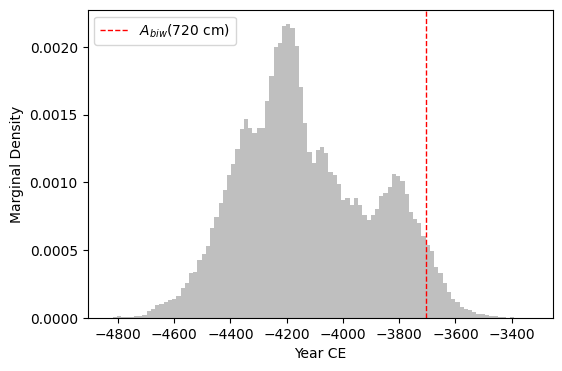

In [15]:
CV_values = data["th"] - data["dc"] * np.sum(samples[-1, :, :index], axis = 1)
fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(CV_values, bins = 100, color = "grey", alpha = 0.5, density = True)
ax.set_xlabel("Year CE")
ax.set_ylabel("Marginal Density")
ax.axvline(x=true_ages[index], color="red", linestyle='--', linewidth = 1, label = data_name + f"({int(interesting_depth)} " + measure + ")")
plt.legend()
# plt.savefig(f"{output_dir}/samples_along_depth_{interesting_depth}.jpg")
plt.show()

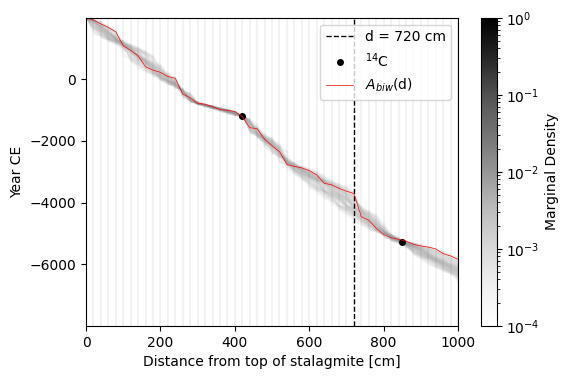

3405

In [16]:
from matplotlib import colors

X = samples[-1, :, :].T
D, N = X.shape

age = np.vstack([
    np.ones((1, N)) * data["th"],
    data["th"] - data["dc"] * np.cumsum(X, axis=0)
])

norm_age = age

# Time bins
dt = 1 if "biw" not in data["dn"] else 10
t_edges = np.arange(np.min(data["d18ort"]), np.max(data["d18ort"]) + dt, dt)
t = t_edges[1:] - dt / 2
T = t.size

# Depth interpolation grid
dz = 0.1 if "biw" not in data["dn"] else 1
z = np.arange(0, data["dc"] * D + dz, dz)
Z = z.size

# Allocate result
C = np.full((Z, T), np.nan)
A = np.array([
    np.interp(z, data["cs"], norm_age[:, j])
    for j in range(N)
]).T

for i in range(Z):
    C[i, :], _ = np.histogram(A[i, :], bins=t_edges, density = True)

fig, ax = plt.subplots(figsize=(6, 4))
plt.set_cmap(plt.cm.Greys)
for i, c in enumerate(data["cs"]):
    if i ==index: 
        ax.axvline(x=c, color='k', linestyle='--', linewidth = 1, label = f"d = {int(interesting_depth)} " + measure)
    else:
        ax.axvline(x=c, color='k', linestyle='--', linewidth = 0.1)

ax.plot(data["c14d"], np.squeeze(data["c14"]), "ko", markersize=4, label = c14_label)
ax.plot(data["cs"], true_ages, color = "red", linewidth=0.5, alpha = 1, label = data_name + "(d)")
im = ax.imshow(
    C.T,
    extent=[z[0], z[-1], t[0], t[-1]],
    origin='lower',
    aspect='auto',
    norm=colors.LogNorm(1e-4, 1),
    interpolation="nearest",
)

plt.legend(loc = "upper right")
cbar = plt.colorbar(im)
cbar.set_label("Marginal Density")
plt.xlabel("Distance from top of stalagmite [" + measure + "]")
plt.ylabel("Year CE")
# plt.savefig(f"{output_dir}/resampled_no_mean.jpg")
plt.show()

del A, C
gc.collect()


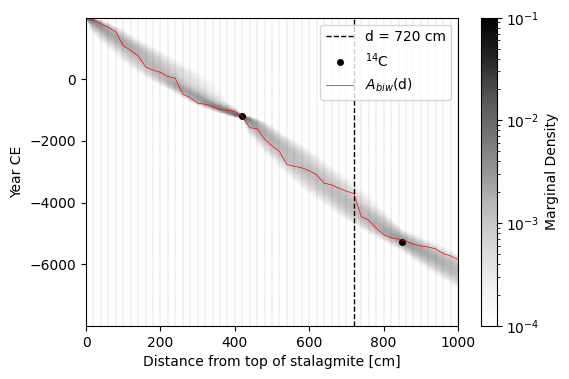

17952

In [17]:
from matplotlib import colors

X = samples[0, :, :].T
D, N = X.shape

age = np.vstack([
    np.ones((1, N)) * data["th"],
    data["th"] - data["dc"] * np.cumsum(X, axis=0)
])

norm_age = age

# Time bins
dt = 1 if "biw" not in data["dn"] else 10
t_edges = np.arange(np.min(data["d18ort"]), np.max(data["d18ort"]) + dt, dt)
t = t_edges[1:] - dt / 2
T = t.size

# Depth interpolation grid
dz = 0.1 if "biw" not in data["dn"] else 1
z = np.arange(0, data["dc"] * D + dz, dz)
Z = z.size

# Allocate result
C = np.full((Z, T), np.nan)
A = np.array([
    np.interp(z, data["cs"], norm_age[:, j])
    for j in range(N)
]).T

for i in range(Z):
    C[i, :], _ = np.histogram(A[i, :], bins=t_edges, density = True)

fig, ax = plt.subplots(figsize=(6, 4))
plt.set_cmap(plt.cm.Greys)
for i, c in enumerate(data["cs"]):
    if i ==index: 
        ax.axvline(x=c, color='k', linestyle='--', linewidth = 1, label = f"d = {int(interesting_depth)} " + measure)
    else:
        ax.axvline(x=c, color='k', linestyle='--', linewidth = 0.1)

ax.plot(data["c14d"], np.squeeze(data["c14"]), "ko", markersize=4, label = c14_label)
ax.plot(data["cs"], true_ages, color = "red", linewidth=0.5, alpha = 1, label = data_name + "(d)")
im = ax.imshow(
    C.T,
    extent=[z[0], z[-1], t[0], t[-1]],
    origin='lower',
    aspect='auto',
    norm=colors.LogNorm(1e-4, 1e-1),
    interpolation = "nearest",
)

plt.legend(loc = "upper right")
cbar = plt.colorbar(im)
cbar.set_label("Marginal Density")
plt.xlabel("Distance from top of stalagmite [" + measure + "]")
plt.ylabel("Year CE")
# plt.savefig(f"{output_dir}/sampled_no_mean.jpg")
plt.show()

del A, C
gc.collect()
